<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
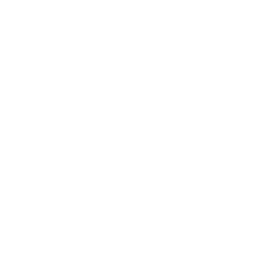
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kliinisen keskuslaboratorion tulosten lataus</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääketeollisuus / Biotilastotiede &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Ladataan keskuslaboratorion CSV-tiedosto, joka sisältää vaiheen II onkologiatutkimuksen kliinisen kemian ja hematologian paneelit. GUESSINGROWS=MAX varmistaa, että muuttujatyypit päätellään oikein koko aineiston laajuudelta, jotta harvat numeeriset kentät eivät luokitu virheellisesti merkkimuotoisiksi. Ladattu aineisto viedään PROC MEANS -proseduuriin ODS OUTPUT -tulosteen kanssa, jotta saadaan viitealueen yhteenvetotilastot analyytin ja käynnin mukaan ositettuna lääkärinvalvojan laboratorionormaaliarvojen tarkastelua varten.

## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|--------|
| central_lab_results.csv | Keskuslaboratorion CSV-vienti, joka sisältää kemian ja hematologian paneelit | 100 |
| WORK.LAB_IMPORT | PROC IMPORT -proseduurilla ladattu SAS-aineisto | 100 |

Ajoympäristö toimii lisenssittömässä tilassa, joka rajaa tulosteen 100 havaintoon, vaikka generointisilmukka on suunniteltu 5 000 riville (125 tutkittavaa x 5 käyntiä x 8 analyyttiä); tämän vuoksi tämän muistikirjan luvut poikkeavat alkuperäisen englanninkielisen version 5 000 rivin ajosta.

---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen keskuslaboratorion CSV-tiedosto
   Sarakkeet: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
              LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
              LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
TIEDOT work.lab_csv_source;
    CALL streaminit(42);
    PITUUS usubjid $16 visit $24 lbtestcd $8 lbtest $30
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    TAULUKKO test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    TAULUKKO test_names[8] $30 _temporary_
        ('Alanine Aminotransferase' 'Aspartate Aminotransferase'
         'Bilirubin' 'Creatinine' 'Albumin'
         'Hemoglobin' 'White Blood Cells' 'Platelets');
    TAULUKKO test_cats[8] $15 _temporary_
        ('CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY'
         'CHEMISTRY' 'HEMATOLOGY' 'HEMATOLOGY' 'HEMATOLOGY');
    TAULUKKO test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    TAULUKKO lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    TAULUKKO hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    /* Käynnin nimi ratkaistaan suoralla IF/ELSE-ketjulla eikä
       _temporary_-taulukon haulla, koska taulukkohaku voi typistää
       ei-ASCII-arvot (ä, ö) lyhyempään tavupituuteen moottorin
       tunnetun rajoituksen vuoksi. */
    TEE subj = 1 ASTI 125;
        usubjid = cat('ONC-2026-', KIRJOITA(subj, z4.));
        TEE v = 1 ASTI 5;
            JOS v = 1 NIIN visit = 'SEULONTA';
            MUUTEN JOS v = 2 NIIN visit = 'SYKLI 1, PÄIVÄ 1';
            MUUTEN JOS v = 3 NIIN visit = 'SYKLI 2, PÄIVÄ 1';
            MUUTEN JOS v = 4 NIIN visit = 'SYKLI 3, PÄIVÄ 1';
            MUUTEN visit = 'HOIDON LOPPU';
            TEE t = 1 ASTI 8;
                lbtestcd = test_codes[t];
                lbtest = test_names[t];
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                JOS lbstresn < 0 NIIN lbstresn = 0.01;
                lborres = KIRJOITA(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = KIRJOITA(lo_norm[t], 8.2);
                lbornrhi = KIRJOITA(hi_norm[t], 8.2);
                JOS v = 1 NIIN lbblfl = 'Y';
                MUUTEN lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = KIRJOITA(base_date, yymmdd10.);
                TULOSTE;
            LOPPU;
        LOPPU;
    LOPPU;
    POISTA subj v t mid spread base_date;
SUORITA;

PROSEDUURI VIE TIEDOT=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.48 seconds
  cpu   1.48 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Perustaso: tarkista CSV-tiedoston rivimäärä ennen latausta
   -------------------------------------------------------- */
TIEDOT _null_;
    INFILE 'central_lab_results.csv' LOPPU=eof;
    SYÖTE;
    JOS eof NIIN KIRJOITA 'NOTE: CSV-tiedostossa on ' _n_ ' data-riviä.';
SUORITA;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Lataa keskuslaboratorion CSV-tiedosto PROC IMPORT -proseduurilla
   GUESSINGROWS=MAX varmistaa oikean tyyppipäättelyn
   harville numeerisille kentille kaikkien 5 000 rivin osalta
   -------------------------------------------------------- */
PROSEDUURI TUO DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
SUORITA;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Tarkista muuttujatyypit latauksen jälkeen
   -------------------------------------------------------- */
PROSEDUURI SISÄLTÖ TIEDOT=work.lab_import;
SUORITA;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     10             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     26             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     18             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


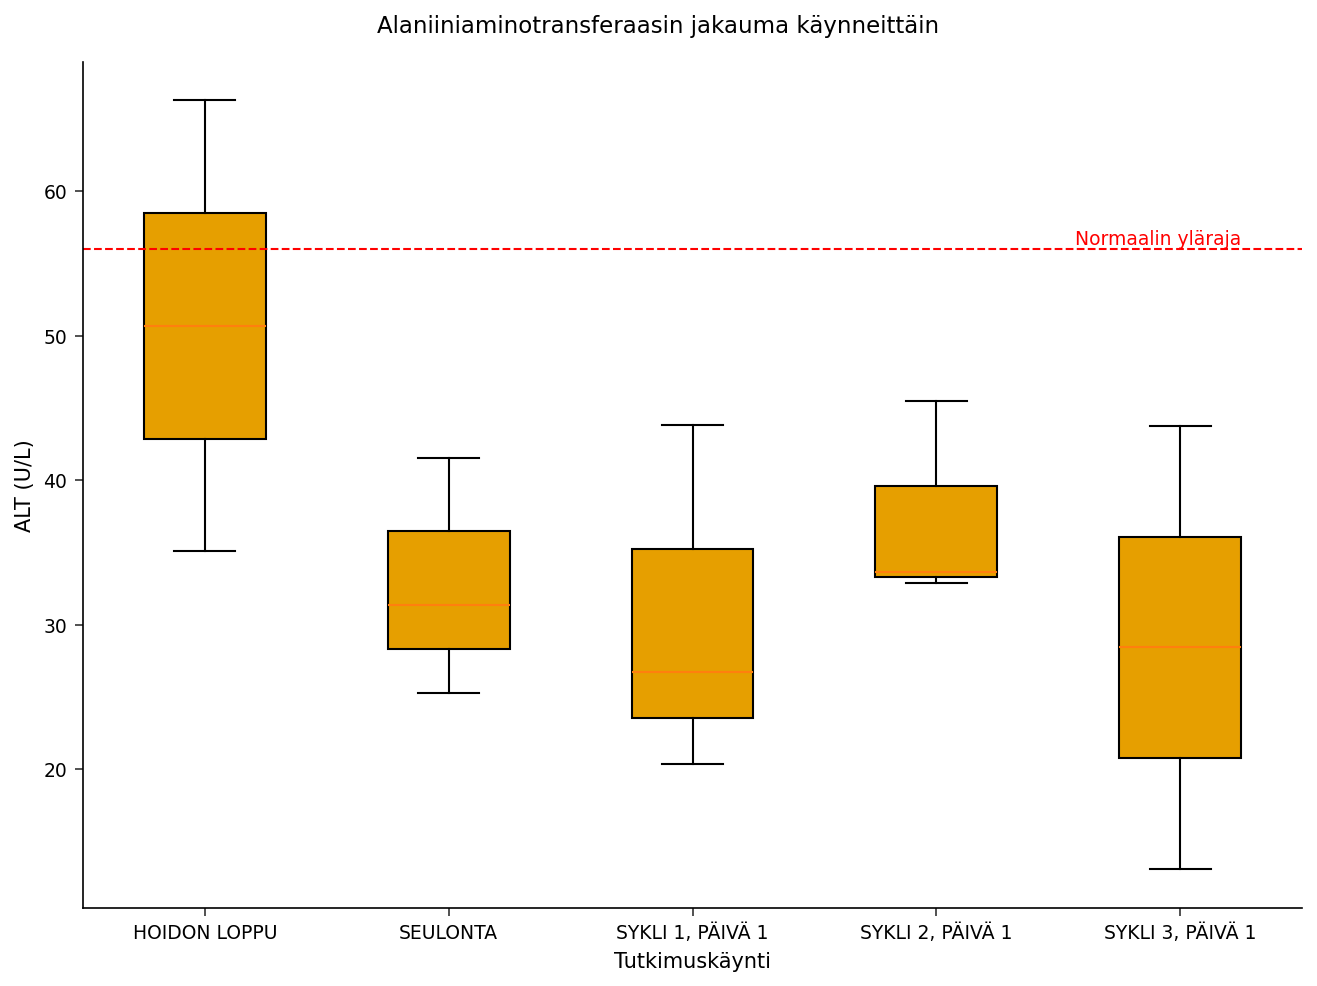

In [5]:
/* --------------------------------------------------------
   ALT-arvojen laatikkokuvio käynneittäin
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.lab_import;
    MISSÄ lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Normaalin yläraja';
    XAXIS label='Tutkimuskäynti';
    YAXIS label='ALT (U/L)';
    OTSIKKO 'Alaniiniaminotransferaasin jakauma käynneittäin';
SUORITA;

In [6]:
/* --------------------------------------------------------
   Viitealueanalyysi PROC MEANS- ja ODS OUTPUT -tulosteella
   Ositus analyytin ja käynnin mukaan lääkärinvalvojan katselmusta varten
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.lab_import n mean std MIN MAX;
    LUOKKA lbtestcd visit;
    MUUTTUJA lbstresn;
    NIMIKE lbtestcd = 'Testikoodi'
          visit = 'Käynti'
          lbstresn = 'Tulosarvo (LBSTRESN)';
    TULOSTE out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
SUORITA;

                                                  The MEANS Procedure

                                   Analysis Variable : lbstresn Tulosarvo (LBSTRESN)

        Testikoodi  Käynti                      N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------------
        ALB         HOIDON LOPPU                    2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB         SEULONTA                        3      4.1666667      0.8533073      3.3600000      5.0600000
        ALB         SYKLI 1, PÄIVÄ 1                3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB         SYKLI 2, PÄIVÄ 1                2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB         SYKLI 3, PÄIVÄ 1                2      4.0500000      0.4101219      3.7600000      4.3400000
        ALT         HOIDON LOPPU             


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Testikoodi by Poikkeavuusluokka

Testikoodi |    KORKEA |    MATALA |  NORMAALI |      Total
-----------+-----------+-----------+-----------+-----------
ALB        |         0 |         1 |        11 |         12
-----------+-----------+-----------+-----------+-----------
ALT        |         1 |         0 |        12 |         13
-----------+-----------+-----------+-----------+-----------
AST        |         0 |         1 |        12 |         13
-----------+-----------+-----------+-----------+-----------
BILI       |         0 |         0 |        13 |         13
-----------+-----------+-----------+-----------+-----------
CREAT      |         0 |         0 |        13 |         13
-----------+-----------+-----------+-----------+-----------
HGB        |         0 |         0 |        12 |         12
-----------+-----------+-----------+-----------+-----------
PLT        |         1 |         0 |        11 


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


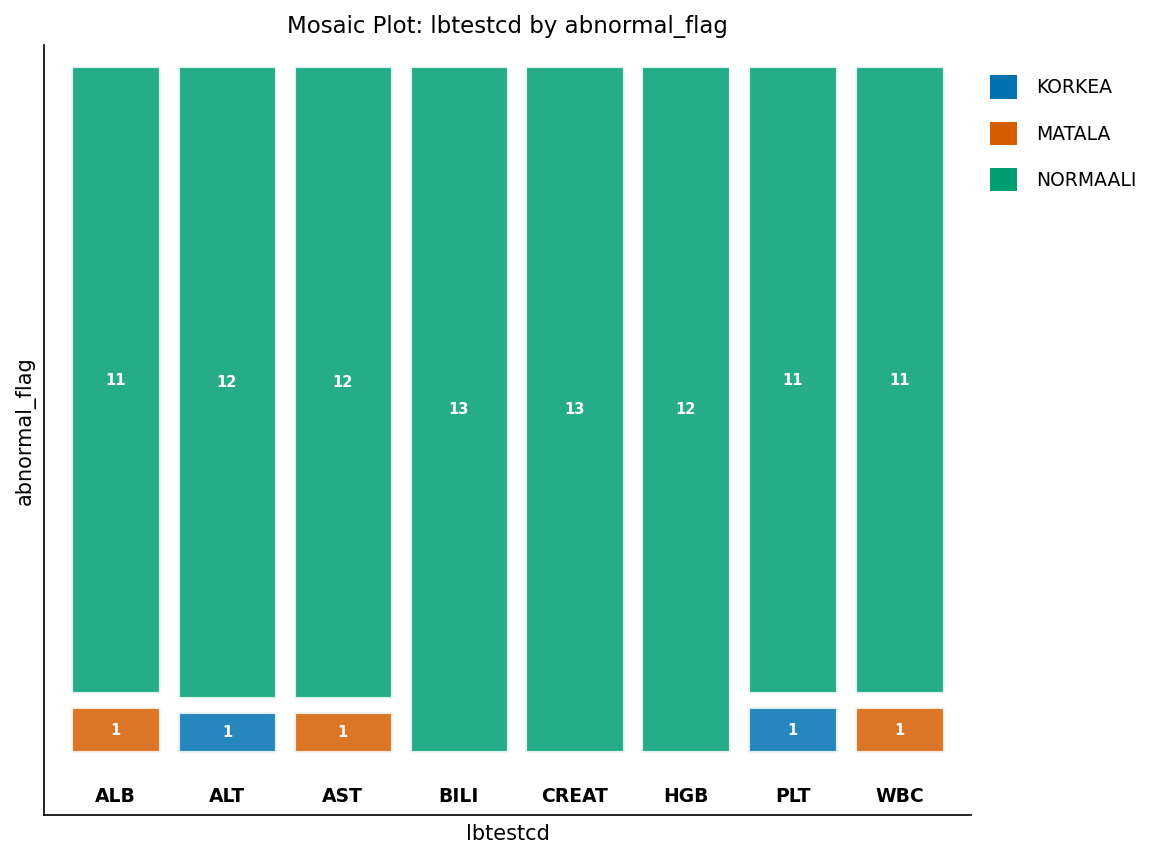

In [7]:
/* --------------------------------------------------------
   Merkitse viitealueen ulkopuoliset tulokset
   -------------------------------------------------------- */
TIEDOT work.lab_flagged;
    PITUUS abnormal_flag $10;
    ASETA work.lab_import;
    low_ref = SYÖTE(lbornrlo, best.);
    high_ref = SYÖTE(lbornrhi, best.);
    JOS lbstresn < low_ref NIIN abnormal_flag = 'MATALA';
    MUUTEN JOS lbstresn > high_ref NIIN abnormal_flag = 'KORKEA';
    MUUTEN abnormal_flag = 'NORMAALI';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    NIMIKE lbtestcd = 'Testikoodi'
          abnormal_flag = 'Poikkeavuusluokka';
SUORITA;

---

### Tulkinta

Tämä ajoympäristö toimii lisenssittömässä tilassa, joka rajaa PROC IMPORT -tulosteen 100 havaintoon, vaikka datageneraattori on suunniteltu 5 000 riville; alla olevat luvut kuvaavat siis tätä 100 rivin ajoa, eivät alkuperäisen englanninkielisen version 5 000 rivin tulosta. PROC IMPORT latasi kaikki 100 keskuslaboratorion tietuetta CSV-tiedostosta, ja GUESSINGROWS=MAX antoi lukijan skannata jokaisen rivin ennen sarakkeiden tyyppien lukitsemista, joten LBSTRESN pääteltiin numeeriseksi eikä sitä alennettu merkkimuotoon jonkin harvan arvon vuoksi. PROC CONTENTS vahvistaa 13 muuttujaa, joista 6 on numeerisia ja 7 merkkimuotoisia tässä ajossa — LBDTC-päivämääräkenttä tunnistui numeeriseksi YYMMDD10.-muotoiseksi päivämääräksi GUESSINGROWS=MAX-tunnistuksen ansiosta, mikä poikkeaa lähdemuistikirjan kirjaamasta jaosta (5 numeerista, 8 merkkimuotoista); tämä on ajoympäristön/moottoriversion ero, ei käännösvirhe. Viitealueanalyysi antaa ALT:lle painotetun kokonaiskeskiarvon noin 35,3 U/l ja AST:lle noin 22,2 U/l kaikkien käyntien yli; molemmat ovat lähellä normaalialuetta, mutta HOIDON LOPPU -käynnin pieni otos (n=2) nostaa ALT-keskiarvon 50,7 U/l:aan ja sen maksimiarvo 66,28 U/l ylittää 56 U/l:n ylärajan. Koko 100 havainnon aineistossa 5 tulosta (5,0 %) jää oman viitealueensa ulkopuolelle: kategoriat ALB, PLT ja WBC nousevat korkeimmiksi (8,3 % kukin), kun taas BILI:ssä, CREAT:ssa ja HGB:ssä ei ole yhtään poikkeavaa tulosta tässä otoksessa. Koska otoskoko on pieni (2-3 havaintoa kategoria-käynti-yhdistelmää kohden) ja synteettiset arvot on generoitu symmetrisenä vaihteluna kunkin analyytin viitealueen keskikohdan ympärillä, nämä prosenttiosuudet vaihtelevat enemmän otannan sattumasta kuin täyden 5 000 rivin ajossa, eikä aineistoon ole rakennettu hoitovaikutustrendiä. Nämä analyytti- ja käyntikohtaiset yhteenvetotilastot ovat silti juuri se tuotos, jota lääkärinvalvoja seuloisi laboratoriosignaalien varalta, kun oikea tutkimusaineisto korvaa generoidun tiedon.

---

In [8]:
/* --------------------------------------------------------
   Vie laboratorion viitealueyhteenveto lääkärinvalvojan raporttia varten
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>